# ColonySearch — Network Hyperparameter Tuning

Compares **PSO**, **QPSO**, **Grid Search**, and **Random Search** on **whole-network** search quality.
Every evaluation builds a fresh network with the candidate parameters, runs warm-up queries, then
measures NDCG@k on the held-out test set.

**Parameters tuned** (7 dimensions):

| # | Parameter | What it controls |
|---|-----------|------------------|
| 0 | `REP_WEIGHT` | How much a node's reputation nudges result scores vs. raw content |
| 1 | `REP_DECAY` | EMA learning rate for reputation (low = stable, high = reactive) |
| 2 | `PHEROMONE_EVAP` | How fast pheromone trails fade (low = long memory, high = explores more) |
| 3 | `ACO_ALPHA` | Pheromone exponent in neighbor selection (>1 = exploit strong trails) |
| 4 | `ACO_BETA` | Reputation exponent in neighbor selection (>1 = exploit high-rep nodes) |
| 5 | `edge_probability` | Mesh density — more edges = richer ACO but more queries per hop |
| 6 | `top_k` | Neighbors sampled per hop — more = better recall, slower |

Metric: **NDCG@3** — ground truth = union of relevant documents across all nodes for each query.

In [11]:
import sys
import contextlib
import io
import json
import random
import time
import importlib
from pathlib import Path
from math import log2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Walk up until project root (works wherever Jupyter is launched)
_ROOT = Path().resolve()
for _ in range(6):
    if (_ROOT / 'data' / 'dbs').exists():
        break
    _ROOT = _ROOT.parent
sys.path.insert(0, str(_ROOT))

from data.tuning.ground_truth import generate_llm_doc_queries, load_shared_ground_truth
from data.tuning.algos.pso import PSO
from data.tuning.algos.qpso import QPSO
from data.tuning.algos.grid_search import GridSearch
from data.tuning.algos.random_search import RandomSearch

DATA_DIR = _ROOT / 'data'
K = 3
print(f'Project root: {_ROOT}')

Project root: /home/lukas/Documents/Uni/THN/IntroBC/ColonySearch


## Parameter Bounds

Search ranges for all seven network parameters.  
Edit here to explore different parts of the space.

In [12]:
# [min, max] for each parameter in this fixed order:
#  [REP_WEIGHT, REP_DECAY, PHEROMONE_EVAP, ACO_ALPHA, ACO_BETA, edge_probability, top_k]
NET_BOUNDS = [
    (0.0,  0.8),   # REP_WEIGHT      — 0 = pure content, 0.8 = heavy rep bias
    (0.01, 0.5),   # REP_DECAY       — EMA rate; >0.5 makes rep nearly memoryless
    (0.01, 0.5),   # PHEROMONE_EVAP  — evaporation ρ; >0.5 trails reset too fast
    (0.5,  3.0),   # ACO_ALPHA       — pheromone exponent
    (0.5,  3.0),   # ACO_BETA        — reputation exponent
    (0.1,  0.9),   # edge_probability — mesh density
    (1,    10),    # top_k           — neighbors sampled per hop (rounded to int)
]

PARAM_LABELS = [
    'REP_WEIGHT      (0=content, 1=rep)',
    'REP_DECAY       (EMA rate)',
    'PHEROMONE_EVAP  (evaporation p)',
    'ACO_ALPHA       (pheromone exponent)',
    'ACO_BETA        (reputation exponent)',
    'edge_probability (mesh density)',
    'top_k           (neighbors per hop, int)',
]

print('Parameter bounds:')
for (lo, hi), label in zip(NET_BOUNDS, PARAM_LABELS):
    print(f'  {label}')
    print(f'      range: [{lo}, {hi}]')
print()
print('NET_BOUNDS:', NET_BOUNDS)

Parameter bounds:
  REP_WEIGHT      (0=content, 1=rep)
      range: [0.0, 0.8]
  REP_DECAY       (EMA rate)
      range: [0.01, 0.5]
  PHEROMONE_EVAP  (evaporation p)
      range: [0.01, 0.5]
  ACO_ALPHA       (pheromone exponent)
      range: [0.5, 3.0]
  ACO_BETA        (reputation exponent)
      range: [0.5, 3.0]
  edge_probability (mesh density)
      range: [0.1, 0.9]
  top_k           (neighbors per hop, int)
      range: [1, 10]

NET_BOUNDS: [(0.0, 0.8), (0.01, 0.5), (0.01, 0.5), (0.5, 3.0), (0.5, 3.0), (0.1, 0.9), (1, 10)]


In [13]:
# ── Ground truth ──────────────────────────────────────────────────────────────
# Reuse the same LLM-generated queries from the local tuner.
# Relevant URLs are pooled across all nodes so the metric reflects
# what the whole network can collectively return.

LLM_QUERY_COUNT  = 50
LLM_QUERY_CACHE  = DATA_DIR / 'tuning' / 'llm_queries.json'
LLM_QUERY_SEED   = None      # set int for reproducible sampling
LLM_ALLOW_FILL   = False     # set True to call the LLM for missing cache entries
QUERY_SAMPLE_SIZE = 40       # keep small — each eval runs the full network per query
# Round-robin warmup: each node is used as root ⌈N_WARMUP_QUERIES/n_nodes⌉ times.
# 20 = 2 full passes over all 10 nodes — enough to seed pheromone gradients without
# burning the whole evaluation budget on warmup.  Increase to 50+ for "warm" eval.
N_WARMUP_QUERIES  = 50

print('Loading ground truth across all nodes ...')
queries = generate_llm_doc_queries(
    DATA_DIR,
    n_queries=LLM_QUERY_COUNT,
    cache_path=LLM_QUERY_CACHE,
    seed=LLM_QUERY_SEED,
    allow_llm_fill=LLM_ALLOW_FILL,
)

# load_shared_ground_truth returns one test case per (query, node) pair.
# We collapse them: for each unique query, pool relevant_urls from all nodes.
per_node_cases = load_shared_ground_truth(DATA_DIR, queries)

pooled: dict[str, set] = {}
for tc in per_node_cases:
    qt = tc['query_text']
    pooled.setdefault(qt, set()).update(tc.get('relevant_urls', set()))

network_test_cases = [
    {'query_text': qt, 'relevant_urls': urls}
    for qt, urls in pooled.items()
    if urls
]

total = len(network_test_cases)
if QUERY_SAMPLE_SIZE and total > QUERY_SAMPLE_SIZE:
    rng_sample = random.Random(0)
    network_test_cases = rng_sample.sample(network_test_cases, QUERY_SAMPLE_SIZE)
    print(f'Sampled {QUERY_SAMPLE_SIZE} queries from {total} total')

print(f'\nEvaluating on {len(network_test_cases)} unique queries')
print('Preview:')
for tc in network_test_cases[:10]:
    print(f"  - {tc['query_text'][:100]}  ({len(tc['relevant_urls'])} relevant docs)")

Loading ground truth across all nodes ...
Using 50 cached LLM queries
  Node_1: 50 shared test cases
  Node_10: 50 shared test cases
  Node_2: 50 shared test cases
  Node_3: 50 shared test cases
  Node_4: 50 shared test cases
  Node_5: 50 shared test cases
  Node_6: 50 shared test cases
  Node_7: 50 shared test cases
  Node_8: 50 shared test cases
  Node_9: 50 shared test cases
Sampled 40 queries from 50 total

Evaluating on 40 unique queries
Preview:
  - NTR Dutch public broadcaster Wikipedia  (1 relevant docs)
  - National Authority for Remote Sensing and Space Sciences Wikipedia  (70 relevant docs)
  - Economic and Social Research Council UKRI Swindon  (84 relevant docs)
  - G-SimCLR self-supervised contrastive learning pseudo labelling  (5 relevant docs)
  - carbon pricing effect on technological change energy decarbonization  (2 relevant docs)
  - Tertullian De Pudicitia Pope Callixtus I adultery  (26 relevant docs)
  - ManufacturingTomorrow articles stories interviews reviews new

## Network Evaluation Harness

Each call to `network_evaluate(params, ...)` does:
1. Patches the five `node.py` module-level globals.
2. Builds a fresh `Network` with the candidate `edge_probability` (and fresh pheromones/reputations reset to defaults).
3. Runs `N_WARMUP_QUERIES` in **round-robin** order — every node is used as root at least twice — so pheromone and reputation gradients have at least some signal before measurement.
4. Evaluates NDCG@K, Precision@K and Recall@K for every test query (stdout suppressed).

**On warmup vs. steady-state:**  
The warmup phase is a compromise. True steady-state evaluation would need hundreds of queries to let pheromones/reputation converge, but each network search takes several seconds, so that multiplies the already-expensive evaluation budget by 10×.  
The round-robin warmup (2 full passes over all nodes) is enough to break symmetry and let the ACO routing differentiate edges; it is NOT the same as a fully warm network in production.  
If you want steady-state results: set `N_WARMUP_QUERIES = 50+` and accept the runtime cost, or run a dedicated burn-in study separately.

In [14]:
import node as _node_mod
import importlib
importlib.reload(_node_mod)  # ensure we pick up NETWORK_TOP_K if running stale
from network import Network

# Must be absolute — Jupyter sets CWD to the notebook dir (data/tuning/),
# so relative "data/dbs/Node_N" would silently create an empty SQLite file
# there instead of finding the real DB under _ROOT.  Empty DB → BM25 hits
# OperationalError (caught silently in search.py), KNN path missing →
# search() returns [] → every NDCG = 0.0.
NODE_IDS = [str(_ROOT / f'data/dbs/Node_{i}') for i in range(1, 11)]


def _ndcg_at_k(ranked_urls: list, relevant_urls: set, k: int) -> float:
    if not relevant_urls:
        return 0.0
    actual = sum(
        1.0 / log2(i + 1)
        for i, url in enumerate(ranked_urls[:k], start=1)
        if url in relevant_urls
    )
    ideal_len = min(len(relevant_urls), k)
    ideal = sum(1.0 / log2(i + 1) for i in range(1, ideal_len + 1))
    return actual / ideal if ideal else 0.0


def _precision_at_k(ranked_urls: list, relevant_urls: set, k: int) -> float:
    if k == 0:
        return 0.0
    hits = sum(1 for url in ranked_urls[:k] if url in relevant_urls)
    return hits / k


def _recall_at_k(ranked_urls: list, relevant_urls: set, k: int) -> float:
    if not relevant_urls:
        return 0.0
    hits = sum(1 for url in ranked_urls[:k] if url in relevant_urls)
    return hits / len(relevant_urls)


def _build_network(edge_prob: float, seed: int = 42) -> tuple:
    """Build a fresh Network + Node objects. Returns (net, nodes_dict)."""
    net = Network.build_random_mesh(NODE_IDS, edge_probability=edge_prob, seed=seed)
    nodes = {}
    for nid in NODE_IDS:
        n = _node_mod.Node(nid, net, nid)
        net.attach_node_obj(nid, n)
        nodes[nid] = n
    return net, nodes


def network_evaluate(
    params,
    test_cases: list,
    k: int = K,
    n_warmup: int = N_WARMUP_QUERIES,
    seed: int = 42,
) -> dict:
    """
    params = [REP_WEIGHT, REP_DECAY, PHEROMONE_EVAP, ACO_ALPHA, ACO_BETA,
              edge_probability, top_k]
    Returns dict with mean_ndcg, mean_precision, mean_recall, per_query_ndcg.
    """
    rep_w, rep_d, phero, alpha, beta, edge_prob, top_k_raw = params

    # Patch node.py globals
    _node_mod.REP_WEIGHT      = float(rep_w)
    _node_mod.REP_DECAY       = float(rep_d)
    _node_mod.PHEROMONE_EVAP  = float(phero)
    _node_mod.ACO_ALPHA       = float(alpha)
    _node_mod.ACO_BETA        = float(beta)
    _node_mod.NETWORK_TOP_K   = max(1, int(round(float(top_k_raw))))

    _, nodes = _build_network(float(edge_prob), seed=seed)
    rng = random.Random(seed)

    # Round-robin warmup — cycle every node as root so every edge gets at least
    # one pheromone deposit before we measure.  Random selection with n=5 could
    # miss half the nodes entirely; round-robin guarantees coverage.
    warmup_queries = test_cases * (n_warmup // len(test_cases) + 1)
    for i in range(n_warmup):
        root_id = NODE_IDS[i % len(NODE_IDS)]
        root = nodes[root_id]
        with contextlib.redirect_stdout(io.StringIO()):
            root.search(warmup_queries[i]['query_text'])

    # Evaluation
    ndcg_scores: list[float] = []
    prec_scores: list[float] = []
    rec_scores:  list[float] = []

    for tc in test_cases:
        root = nodes[rng.choice(NODE_IDS)]
        with contextlib.redirect_stdout(io.StringIO()):
            results = root.search(tc['query_text'])
        ranked_urls = [r.get('url', '') for r in results]
        rel = tc['relevant_urls']
        ndcg_scores.append(_ndcg_at_k(ranked_urls, rel, k))
        prec_scores.append(_precision_at_k(ranked_urls, rel, k))
        rec_scores.append(_recall_at_k(ranked_urls, rel, k))

    def _mean(lst): return float(sum(lst) / len(lst)) if lst else 0.0

    return {
        'mean_ndcg':      _mean(ndcg_scores),
        'mean_precision': _mean(prec_scores),
        'mean_recall':    _mean(rec_scores),
        'per_query_ndcg': ndcg_scores,
    }


print('network_evaluate ready.')
print(f'NODE_IDS[0]: {NODE_IDS[0]}')  # verify absolute path

network_evaluate ready.
NODE_IDS[0]: /home/lukas/Documents/Uni/THN/IntroBC/ColonySearch/data/dbs/Node_1


In [15]:
# ── Sanity sweep ──────────────────────────────────────────────────────────────
# Quick check that the objective varies meaningfully across random param vectors.
# Uses only 10 test cases to keep it fast.

rng_sweep = np.random.default_rng(0)
n_points   = 5
sample_cases = network_test_cases[:min(10, len(network_test_cases))]

def _rand_params(rng):
    return [rng.uniform(lo, hi) for (lo, hi) in NET_BOUNDS]

sweep_rows = []
for i in range(n_points):
    p = _rand_params(rng_sweep)
    m = network_evaluate(p, sample_cases, k=K)
    sweep_rows.append({
        'REP_WEIGHT':  round(p[0], 3),
        'REP_DECAY':   round(p[1], 3),
        'PHERO_EVAP':  round(p[2], 3),
        'ACO_ALPHA':   round(p[3], 2),
        'ACO_BETA':    round(p[4], 2),
        'edge_prob':   round(p[5], 2),
        'top_k':       int(round(p[6])),
        f'NDCG@{K}':   round(m['mean_ndcg'], 4),
    })
    print(f'  [{i+1}/{n_points}] NDCG@{K}={m["mean_ndcg"]:.4f}')

df_sweep = pd.DataFrame(sweep_rows).sort_values(f'NDCG@{K}', ascending=False)
display(df_sweep)
print(f'NDCG std: {df_sweep[f"NDCG@{K}"].std():.4f}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  [1/5] NDCG@3=0.8082
  [2/5] NDCG@3=0.3765
  [3/5] NDCG@3=0.1939
  [4/5] NDCG@3=0.8379
  [5/5] NDCG@3=0.8613


,REP_WEIGHT,REP_DECAY,PHERO_EVAP,ACO_ALPHA,ACO_BETA,edge_prob,top_k,NDCG@3
4,0.548,0.329,0.347,1.47,0.84,0.68,6,0.8613
3,0.099,0.339,0.327,2.04,1.46,0.90,10,0.8379
0,0.510,0.142,0.030,0.54,2.53,0.83,6,0.8082
1,0.584,0.276,0.468,2.54,0.51,0.79,1,0.3765
2,0.584,0.096,0.433,1.85,1.25,0.44,1,0.1939


NDCG std: 0.3090


## Algorithm Configuration

**Note on runtime:** Each evaluation queries the whole network (10 nodes, multi-hop).  
Full budget (~600 PSO evals × 30 queries) can take several hours.  
Use the **quick test** block instead for a first pass.

In [16]:
def make_objective(test_cases, k):
    def objective(params):
        return -network_evaluate(params, test_cases, k=k)['mean_ndcg']
    return objective

objective_fn = make_objective(network_test_cases, K)

# ── Full budget ───────────────────────────────────────────────────────────────
algos = [
    ('PSO',    PSO(bounds=NET_BOUNDS,    n_particles=20, max_iter=15)),
    ('QPSO',   QPSO(bounds=NET_BOUNDS,   n_particles=20, max_iter=15)),
    ('Grid',   GridSearch(bounds=NET_BOUNDS, n_per_dim=3)),
    ('Random', RandomSearch(bounds=NET_BOUNDS, n_evaluations=100)),
]

# ── Quick test (~25 evals total, ~15 minutes) ─────────────────────────────────
"""algos = [
     ('PSO',    PSO(bounds=NET_BOUNDS,    n_particles=4, max_iter=3)),
     ('QPSO',   QPSO(bounds=NET_BOUNDS,   n_particles=4, max_iter=3)),
     ('Grid',   GridSearch(bounds=NET_BOUNDS, n_per_dim=2)),
     ('Random', RandomSearch(bounds=NET_BOUNDS, n_evaluations=12)),
 ]"""

results = {}
for name, algo in algos:
    t0 = time.time()
    print(f'Running {name} ...')
    results[name] = algo.optimize(objective_fn)
    elapsed = time.time() - t0
    print(f'  Best NDCG@{K}: {-results[name].best_fitness:.4f}  '
          f'({results[name].n_evals} evals, {elapsed:.0f}s)')

print('\nDone.')

Running PSO ...
  Best NDCG@3: 0.7459  (300 evals, 20783s)
Running QPSO ...
  Best NDCG@3: 0.7518  (300 evals, 27226s)
Running Grid ...


KeyboardInterrupt: 

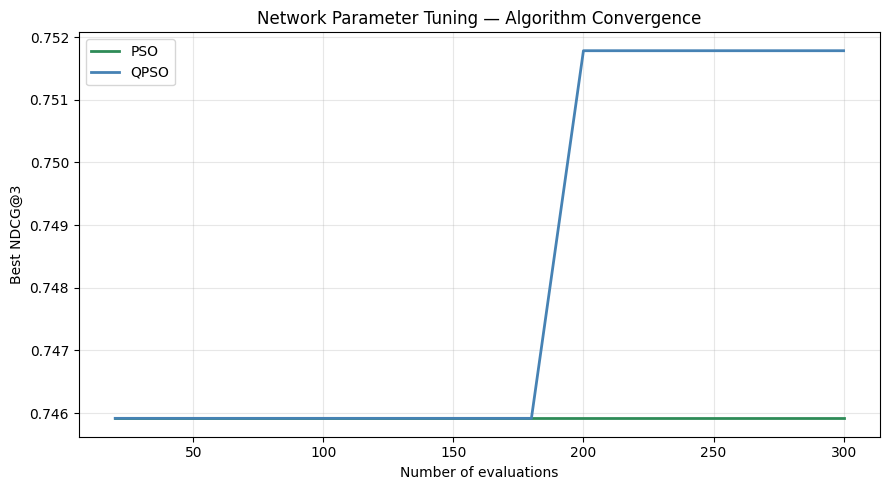

In [17]:
# ── Convergence Graph ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

colors = {'PSO': 'seagreen', 'QPSO': 'steelblue', 'Grid': 'gray', 'Random': 'darkorange'}
for name, res in results.items():
    xs = [h['n_evals']   for h in res.history]
    ys = [h['best_ndcg'] for h in res.history]
    ax.plot(xs, ys, label=name, color=colors[name], linewidth=2)

ax.set_xlabel('Number of evaluations')
ax.set_ylabel(f'Best NDCG@{K}')
ax.set_title('Network Parameter Tuning — Algorithm Convergence')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('network_benchmark_convergence.png', dpi=120)
plt.show()

In [18]:
# ── Results table ─────────────────────────────────────────────────────────────
ndcg_col = f'NDCG@{K}'
prec_col = f'Prec@{K}'
rec_col  = f'Recall@{K}'
rows = []
for name, res in results.items():
    rw, rd, pe, aa, ab, ep, tk = res.best_params
    metrics = network_evaluate(res.best_params, network_test_cases, k=K)
    rows.append({
        'Algorithm':  name,
        ndcg_col:     round(metrics['mean_ndcg'],      4),
        prec_col:     round(metrics['mean_precision'],  4),
        rec_col:      round(metrics['mean_recall'],     4),
        'Total Evals': res.n_evals,
        'REP_WEIGHT': round(rw, 3),
        'REP_DECAY':  round(rd, 3),
        'PHERO_EVAP': round(pe, 3),
        'ACO_ALPHA':  round(aa, 2),
        'ACO_BETA':   round(ab, 2),
        'edge_prob':  round(ep, 2),
        'top_k':      int(round(tk)),
    })

df = pd.DataFrame(rows).set_index('Algorithm')
display(df.style.highlight_max(subset=[ndcg_col, prec_col, rec_col]))

,NDCG@3,Prec@3,Recall@3,Total Evals,REP_WEIGHT,REP_DECAY,PHERO_EVAP,ACO_ALPHA,ACO_BETA,edge_prob,top_k
Algorithm,,,,,,,,,,,
PSO,0.740100,0.533300,0.367900,300,0.172000,0.210000,0.428000,1.080000,0.650000,0.330000,4
QPSO,0.734200,0.525000,0.367100,300,0.185000,0.424000,0.500000,1.990000,1.310000,0.510000,5


## Grid Search Heatmap

NDCG@K across `REP_WEIGHT × PHEROMONE_EVAP` with all other params fixed at the best values found.

In [ ]:
# Use the best overall params as the fixed baseline
best_algo   = min(results, key=lambda n: results[n].best_fitness)
best_p      = results[best_algo].best_params
_, _, _, best_aa, best_ab, best_ep, best_tk = best_p

n = 6
rw_vals   = np.linspace(NET_BOUNDS[0][0], NET_BOUNDS[0][1], n)
pe_vals   = np.linspace(NET_BOUNDS[2][0], NET_BOUNDS[2][1], n)

# Fix REP_DECAY at best; sweep REP_WEIGHT x PHEROMONE_EVAP
best_rd = best_p[1]

print(f'Sweeping REP_WEIGHT × PHEROMONE_EVAP  (fixed: REP_DECAY={best_rd:.3f}, '
      f'ACO_ALPHA={best_aa:.2f}, ACO_BETA={best_ab:.2f}, '
      f'edge_prob={best_ep:.2f}, top_k={int(round(best_tk))}) ...')

ndcg_grid = np.zeros((n, n))
for i, rw in enumerate(rw_vals):
    for j, pe in enumerate(pe_vals):
        p = [rw, best_rd, pe, best_aa, best_ab, best_ep, best_tk]
        m = network_evaluate(p, network_test_cases, k=K)
        ndcg_grid[i, j] = m['mean_ndcg']
        print(f'  rw={rw:.2f} pe={pe:.2f}  NDCG={m["mean_ndcg"]:.4f}')

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(ndcg_grid, origin='lower', aspect='auto',
               extent=[pe_vals[0], pe_vals[-1], rw_vals[0], rw_vals[-1]],
               cmap='viridis')
fig.colorbar(im, ax=ax, label=f'NDCG@{K}')
ax.set_xlabel('PHEROMONE_EVAP  (evaporation ρ)')
ax.set_ylabel('REP_WEIGHT  (0=content, 1=rep)')
ax.set_title(f'Grid Heatmap: NDCG@{K} by REP_WEIGHT × PHEROMONE_EVAP')
fig.tight_layout()
fig.savefig('network_heatmap_rw_phero.png', dpi=120)
plt.show()

## Apply Best Parameters to `node.py`

Once you are happy with the results, run this cell to print the constants you should paste into `node.py`.

In [ ]:
best_algo = min(results, key=lambda n: results[n].best_fitness)
best_p    = results[best_algo].best_params
rw, rd, pe, aa, ab, ep, tk = best_p

# Re-evaluate to get all three metrics, not just NDCG
best_metrics = network_evaluate(best_p, network_test_cases, k=K)

print(f'Best algorithm : {best_algo}')
print(f'  NDCG@{K}      : {best_metrics["mean_ndcg"]:.4f}')
print(f'  Precision@{K}  : {best_metrics["mean_precision"]:.4f}')
print(f'  Recall@{K}     : {best_metrics["mean_recall"]:.4f}')
print()
print('Paste the following into node.py:')
print(f'REP_WEIGHT:      float = {rw:.4f}')
print(f'REP_DECAY:       float = {rd:.4f}')
print(f'PHEROMONE_EVAP:  float = {pe:.4f}')
print(f'ACO_ALPHA:       float = {aa:.4f}')
print(f'ACO_BETA:        float = {ab:.4f}')
print(f'NETWORK_TOP_K:   int   = {int(round(tk))}')
print()
print('And pass this to Network.build_random_mesh():')
print(f'edge_probability = {ep:.4f}')